In [ ]:
!pip install opencv-python-headless scikit-image scikit-learn pandas numpy matplotlib tqdm
import cv2, numpy as np, pandas as pd
print("All libraries loaded ")

All libraries loaded 


In [ ]:
from google.colab import files
files.upload()  # A button will appear — click it and select your kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"purnimarrg","key":"5702831860072534e41b3a932fa062cd"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle configured ✓")

Kaggle configured ✓


In [ ]:
!kaggle datasets download -d andrewmvd/bone-marrow-cell-classification
print("Download complete ✓")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/bone-marrow-cell-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 6.46G/6.46G [01:05<00:00, 105MB/s]

Download complete ✓


In [ ]:
!unzip -q bone-marrow-cell-classification.zip -d /content/matek/
print("Unzipped ✓")

Unzipped ✓


In [ ]:
import os, shutil

# Classes we WANT to keep
keep = ['BLA', 'NGS', 'LYT']

base = '/content/matek/'

# Check what folder structure looks like first
print(os.listdir(base))

['abbreviations.csv', 'bone_marrow_cell_dataset']


In [ ]:
import os

base = '/content/matek/bone_marrow_cell_dataset/'
print(os.listdir(base))

['MYB', 'NIF', 'LYI', 'NGS', 'BAS', 'KSC', 'LYT', 'PMO', 'EOS', 'ART', 'EBO', 'OTH', 'PLM', 'NGB', 'MMZ', 'FGC', 'HAC', 'PEB', 'ABE', 'BLA', 'MON']


In [ ]:
#keeping only 3 classes for now
import shutil, os

base = '/content/matek/bone_marrow_cell_dataset/'
keep = ['BLA', 'NGS', 'LYT']

for folder in os.listdir(base):
    if folder not in keep:
        shutil.rmtree(os.path.join(base, folder))
        print(f"Deleted {folder}")

print("\n✓ What's left:")
for c in os.listdir(base):
    count = len(os.listdir(os.path.join(base, c)))
    print(f"  {c}: {count} images")


✓ What's left:
  NGS: 30 images
  LYT: 27 images
  BLA: 12 images


In [ ]:
import cv2
import numpy as np

def segment_nucleus(img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

    # CMYK conversion
    K = 1 - np.max(img, axis=2)
    M = (1 - G - K) / (1 - K + 1e-6)

    # HLS conversion
    hls = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HLS)
    S = hls[:,:,2].astype(np.float32) / 255.0

    # Soft map
    KM = K - M
    MS = M - S
    soft_map = MS - KM

    # Otsu threshold
    soft_norm = cv2.normalize(soft_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, nucleus_mask = cv2.threshold(soft_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return nucleus_mask

def segment_cell_regions(img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # Nucleus mask
    nucleus_mask = segment_nucleus(img_bgr)

    # Whole cell mask
    B = img[:,:,2]
    K = 1 - np.max(img, axis=2)
    Y = (1 - B - K) / (1 - K + 1e-6)
    hls = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HLS)
    S = hls[:,:,2].astype(np.float32) / 255.0
    diff = S - Y
    diff_norm = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, cell_mask = cv2.threshold(diff_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Cytoplasm = whole cell XOR nucleus
    cyto_mask = cv2.bitwise_xor(cell_mask, nucleus_mask)

    return nucleus_mask, cell_mask, cyto_mask

print("Segmentation functions defined ✓")

Segmentation functions defined ✓


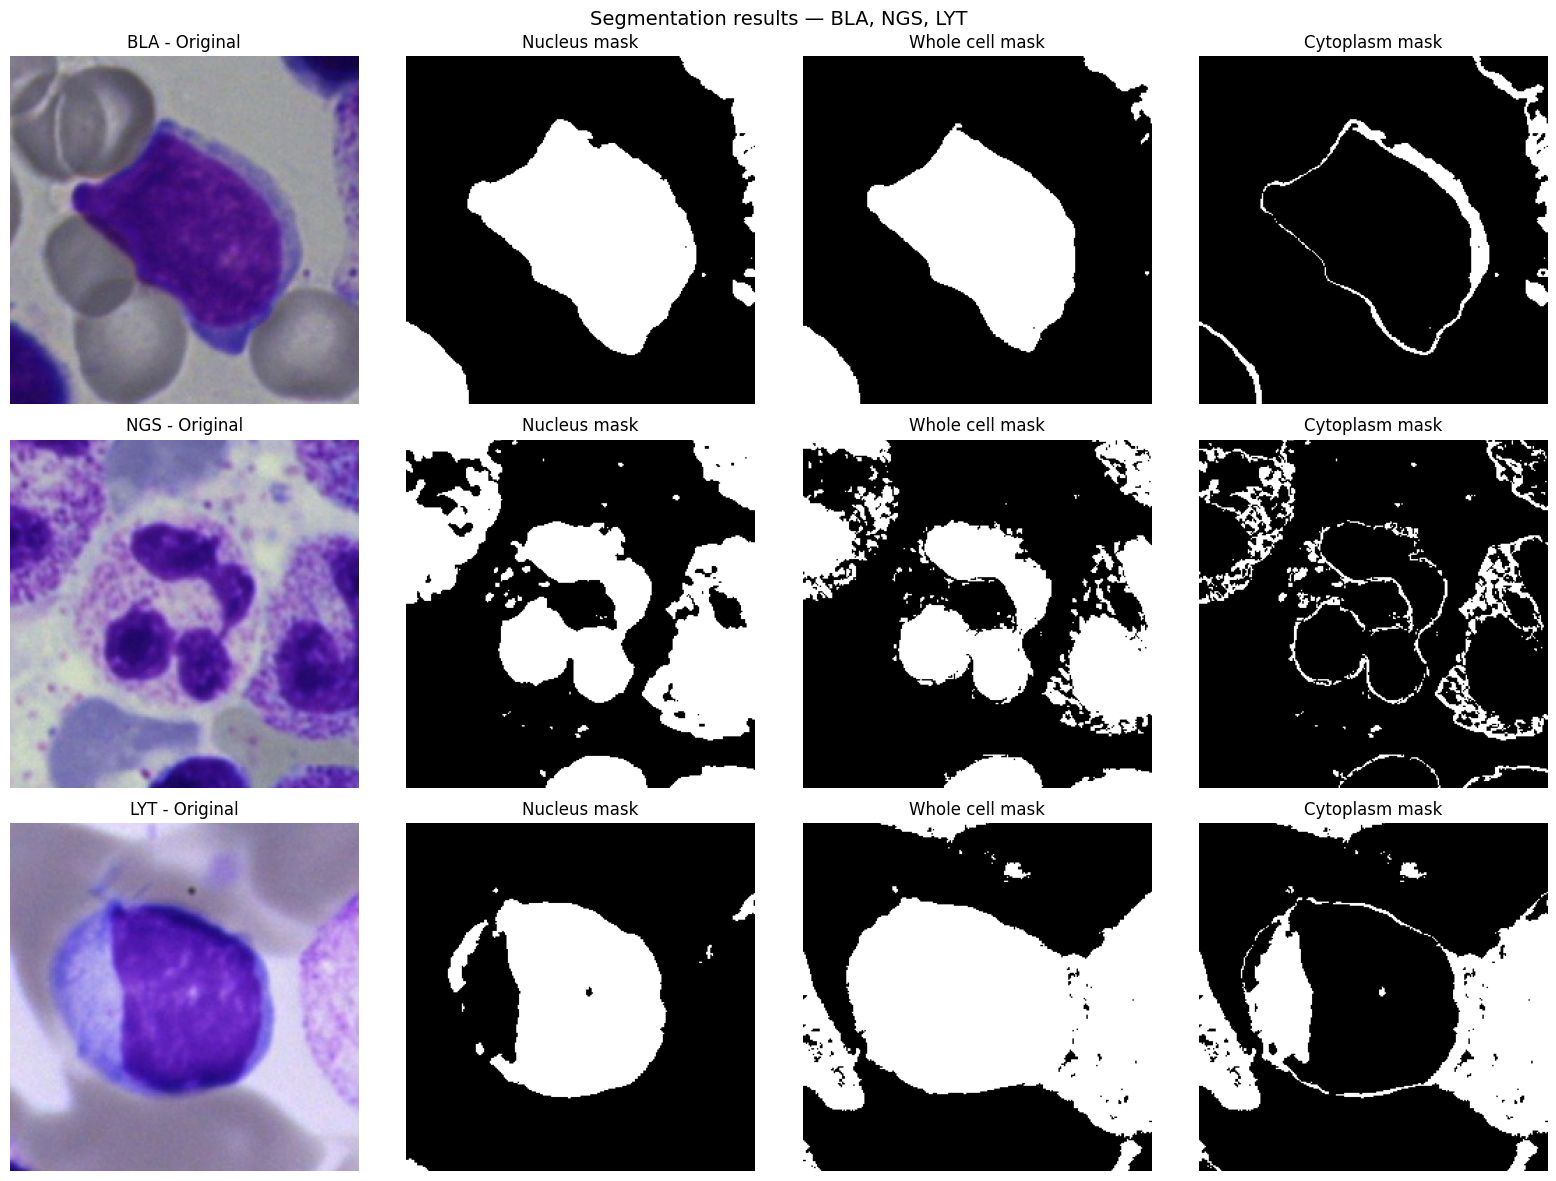

In [ ]:
import matplotlib.pyplot as plt
import os

sample_dir = '/content/sample_3class/'

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, cls in enumerate(['BLA', 'NGS', 'LYT']):
    img_file = os.listdir(os.path.join(sample_dir, cls))[0]
    img_path = os.path.join(sample_dir, cls, img_file)
    img_bgr = cv2.imread(img_path)
    _
    nucleus_mask, cell_mask, cyto_mask = segment_cell_regions(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'{cls} - Original')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(nucleus_mask, cmap='gray')
    axes[row, 1].set_title('Nucleus mask')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(cell_mask, cmap='gray')
    axes[row, 2].set_title('Whole cell mask')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(cyto_mask, cmap='gray')
    axes[row, 3].set_title('Cytoplasm mask')
    axes[row, 3].axis('off')

plt.suptitle('Segmentation results — BLA, NGS, LYT', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-image scipy -q

from skimage.feature import graycomatrix, graycoprops
from scipy import stats as sp_stats

def shape_features(mask):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return [0]*8
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perim = cv2.arcLength(cnt, True)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    convexity = hull_area / (area + 1e-6)
    compactness = (4 * np.pi * area) / (perim**2 + 1e-6)
    x,y,w,h = cv2.boundingRect(cnt)
    elongation = min(w,h) / (max(w,h) + 1e-6)
    M = cv2.moments(cnt)
    if M['m00']:
        mu20=M['mu20']/M['m00']; mu02=M['mu02']/M['m00']; mu11=M['mu11']/M['m00']
        ecc = np.sqrt((mu20-mu02)**2 + 4*mu11**2) / (mu20+mu02+1e-6)
    else: ecc = 0
    roundness = (4*area) / (np.pi*(max(w,h)**2) + 1e-6)
    solidity = area / (hull_area + 1e-6)
    return [convexity, compactness, elongation, ecc, roundness, solidity, area, perim]

def color_features(img_rgb, mask):
    feats = []
    for ch in range(3):
        px = img_rgb[:,:,ch][mask > 0].astype(np.float32)
        if len(px) == 0: feats.extend([0]*5); continue
        feats.append(float(np.mean(px)))
        feats.append(float(np.var(px)))
        feats.append(float(sp_stats.kurtosis(px)))
        feats.append(float(sp_stats.skew(px)))
        hist, _ = np.histogram(px, bins=256, range=(0,255), density=True)
        hist += 1e-10
        feats.append(float(-np.sum(hist * np.log2(hist))))
    return feats

def texture_features(img_gray, mask):
    region = img_gray.copy()
    region[mask == 0] = 0
    glcm = graycomatrix(region, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    feats = []
    for prop in ['contrast','dissimilarity','homogeneity','energy','correlation']:
        feats.append(float(graycoprops(glcm, prop).mean()))
    return feats

print("Feature extraction functions defined ✓")

Feature extraction functions defined ✓


In [ ]:
# Test on one BLA image
test_path = '/content/sample_3class/BLA/' + os.listdir('/content/sample_3class/BLA/')[0]
img_bgr = cv2.imread(test_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

n_mask, c_mask, cy_mask = segment_cell_regions(img_bgr)

# Extract features from nucleus only as a test
shape = shape_features(n_mask)
colour = color_features(img_rgb, n_mask)
texture = texture_features(img_gray, n_mask)

print(f"Shape features ({len(shape)}):  {[round(x,3) for x in shape]}")
print(f"Colour features ({len(colour)}): {[round(x,3) for x in colour]}")
print(f"Texture features ({len(texture)}): {[round(x,3) for x in texture]}")
print(f"\nTotal from nucleus alone: {len(shape)+len(colour)+len(texture)} features")

Shape features (8):  [1.088, 0.624, 0.97, np.float64(0.332), 0.678, 0.919, 15209.0, 553.269]
Colour features (15): [74.2, 554.872, -0.092, 0.331, 6.527, 35.056, 933.976, 0.206, 1.239, 6.168, 133.916, 399.844, 0.397, -0.294, 6.294]
Texture features (5): [137.567, 2.12, 0.786, 0.677, 0.927]

Total from nucleus alone: 28 features


In [ ]:
import cv2
import numpy as np

def is_single_cell(img_bgr):
    """
    Returns True if image contains one clean cell
    Returns False if multiple cells or bad segmentation
    """
    try:
        n_mask, c_mask, cy_mask = segment_cell_regions(img_bgr)

        # Find connected components in nucleus mask
        # Each separate blob = one nucleus
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(n_mask)

        # num_labels includes background so subtract 1
        # Filter out tiny blobs (noise) by requiring area > 1000 pixels
        real_nuclei = [i for i in range(1, num_labels)
                       if stats[i, cv2.CC_STAT_AREA] > 1000]

        # We want exactly ONE nucleus
        if len(real_nuclei) != 1:
            return False, f"found {len(real_nuclei)} nuclei"

        # Also check nucleus is big enough to measure
        nucleus_area = np.sum(n_mask > 0)
        if nucleus_area < 500:
            return False, "nucleus too small"

        return True, "ok"

    except Exception as e:
        return False, str(e)

# Test on your current sample images
sample_dir = '/content/sample_3class/'

for cls in ['BLA', 'NGS', 'LYT']:
    cls_path = os.path.join(sample_dir, cls)
    images = os.listdir(cls_path)[:10]
    good = 0
    bad = 0
    print(f"\n{cls}:")
    for fname in images:
        img_path = os.path.join(cls_path, fname)
        img_bgr = cv2.imread(img_path)
        ok, reason = is_single_cell(img_bgr)
        if ok:
            good += 1
            print(f"  ✓ {fname}")
        else:
            bad += 1
            print(f"  ✗ {fname} — {reason}")
    print(f"  Good: {good}/10  Bad: {bad}/10")


BLA:
  ✗ BLA_03663.jpg — found 3 nuclei
  ✓ BLA_03353.jpg
  ✓ BLA_00822.jpg
  ✓ BLA_03995.jpg
  ✗ BLA_00758.jpg — found 2 nuclei
  ✗ BLA_01928.jpg — found 2 nuclei
  ✓ BLA_06756.jpg
  ✗ BLA_02601.jpg — found 2 nuclei
  ✓ BLA_06928.jpg
  ✓ BLA_06807.jpg
  Good: 6/10  Bad: 4/10

NGS:
  ✗ NGS_16666.jpg — found 5 nuclei
  ✓ NGS_11395.jpg
  ✗ NGS_05721.jpg — found 3 nuclei
  ✓ NGS_13010.jpg
  ✓ NGS_07177.jpg
  ✗ NGS_02616.jpg — found 5 nuclei
  ✗ NGS_08923.jpg — found 3 nuclei
  ✓ NGS_27553.jpg
  ✓ NGS_19402.jpg
  ✗ NGS_00861.jpg — found 2 nuclei
  Good: 5/10  Bad: 5/10

LYT:
  ✓ LYT_18730.jpg
  ✗ LYT_04378.jpg — found 3 nuclei
  ✗ LYT_19088.jpg — found 2 nuclei
  ✗ LYT_25814.jpg — found 3 nuclei
  ✓ LYT_06240.jpg
  ✓ LYT_10453.jpg
  ✗ LYT_11169.jpg — found 2 nuclei
  ✓ LYT_25700.jpg
  ✗ LYT_11063.jpg — found 2 nuclei
  ✗ LYT_16961.jpg — found 3 nuclei
  Good: 4/10  Bad: 6/10


In [ ]:
import os, random, shutil, json, cv2
import numpy as np
from tqdm import tqdm

random.seed(42)

base       = '/content/matek/bone_marrow_cell_dataset/'
sample_dir = '/content/sample_3class/'
os.makedirs(sample_dir, exist_ok=True)

def get_all_images(class_path):
    images = []
    for root, dirs, files in os.walk(class_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.tiff')):
                images.append(os.path.join(root, f))
    return sorted(images)

good_files = {}

for cls in ['BLA', 'NGS', 'LYT']:
    print(f"\nScanning {cls}...")
    all_imgs   = get_all_images(os.path.join(base, cls))
    candidates = random.sample(all_imgs, min(3000, len(all_imgs)))

    good = []
    bad  = 0

    for img_path in tqdm(candidates, desc=cls):
        if len(good) == 1000:
            break
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            bad += 1
            continue
        ok, reason = is_single_cell(img_bgr)
        if ok:
            good.append(img_path)
        else:
            bad += 1

    good_files[cls] = good

    # Copy good images into sample folder
    out_dir = os.path.join(sample_dir, cls)
    os.makedirs(out_dir, exist_ok=True)

    # Clear existing images first
    for f in os.listdir(out_dir):
        os.remove(os.path.join(out_dir, f))

    for img_path in good:
        shutil.copy(img_path, out_dir)

    print(f"  ✓ Good: {len(good)}  |  ✗ Skipped: {bad}")
    print(f"  ✓ Copied to {out_dir}")

# Save file list to Drive
save_path = '/content/drive/MyDrive/dissertation/good_files.json'
with open(save_path, 'w') as f:
    json.dump(good_files, f)

print("\n✓ good_files.json saved to Drive")
print("\nFinal counts:")
for cls in ['BLA', 'NGS', 'LYT']:
    count = len(os.listdir(os.path.join(sample_dir, cls)))
    print(f"  {cls}: {count} images")


Scanning BLA...


BLA:  51%|█████     | 1526/3000 [00:16<00:16, 90.91it/s] 


  ✓ Good: 1000  |  ✗ Skipped: 526
  ✓ Copied to /content/sample_3class/BLA

Scanning NGS...


NGS:  96%|█████████▌| 2873/3000 [00:33<00:01, 85.39it/s]


  ✓ Good: 1000  |  ✗ Skipped: 1873
  ✓ Copied to /content/sample_3class/NGS

Scanning LYT...


LYT:  73%|███████▎  | 2181/3000 [00:26<00:10, 80.80it/s]


  ✓ Good: 1000  |  ✗ Skipped: 1181
  ✓ Copied to /content/sample_3class/LYT

✓ good_files.json saved to Drive

Final counts:
  BLA: 1000 images
  NGS: 1000 images
  LYT: 1000 images


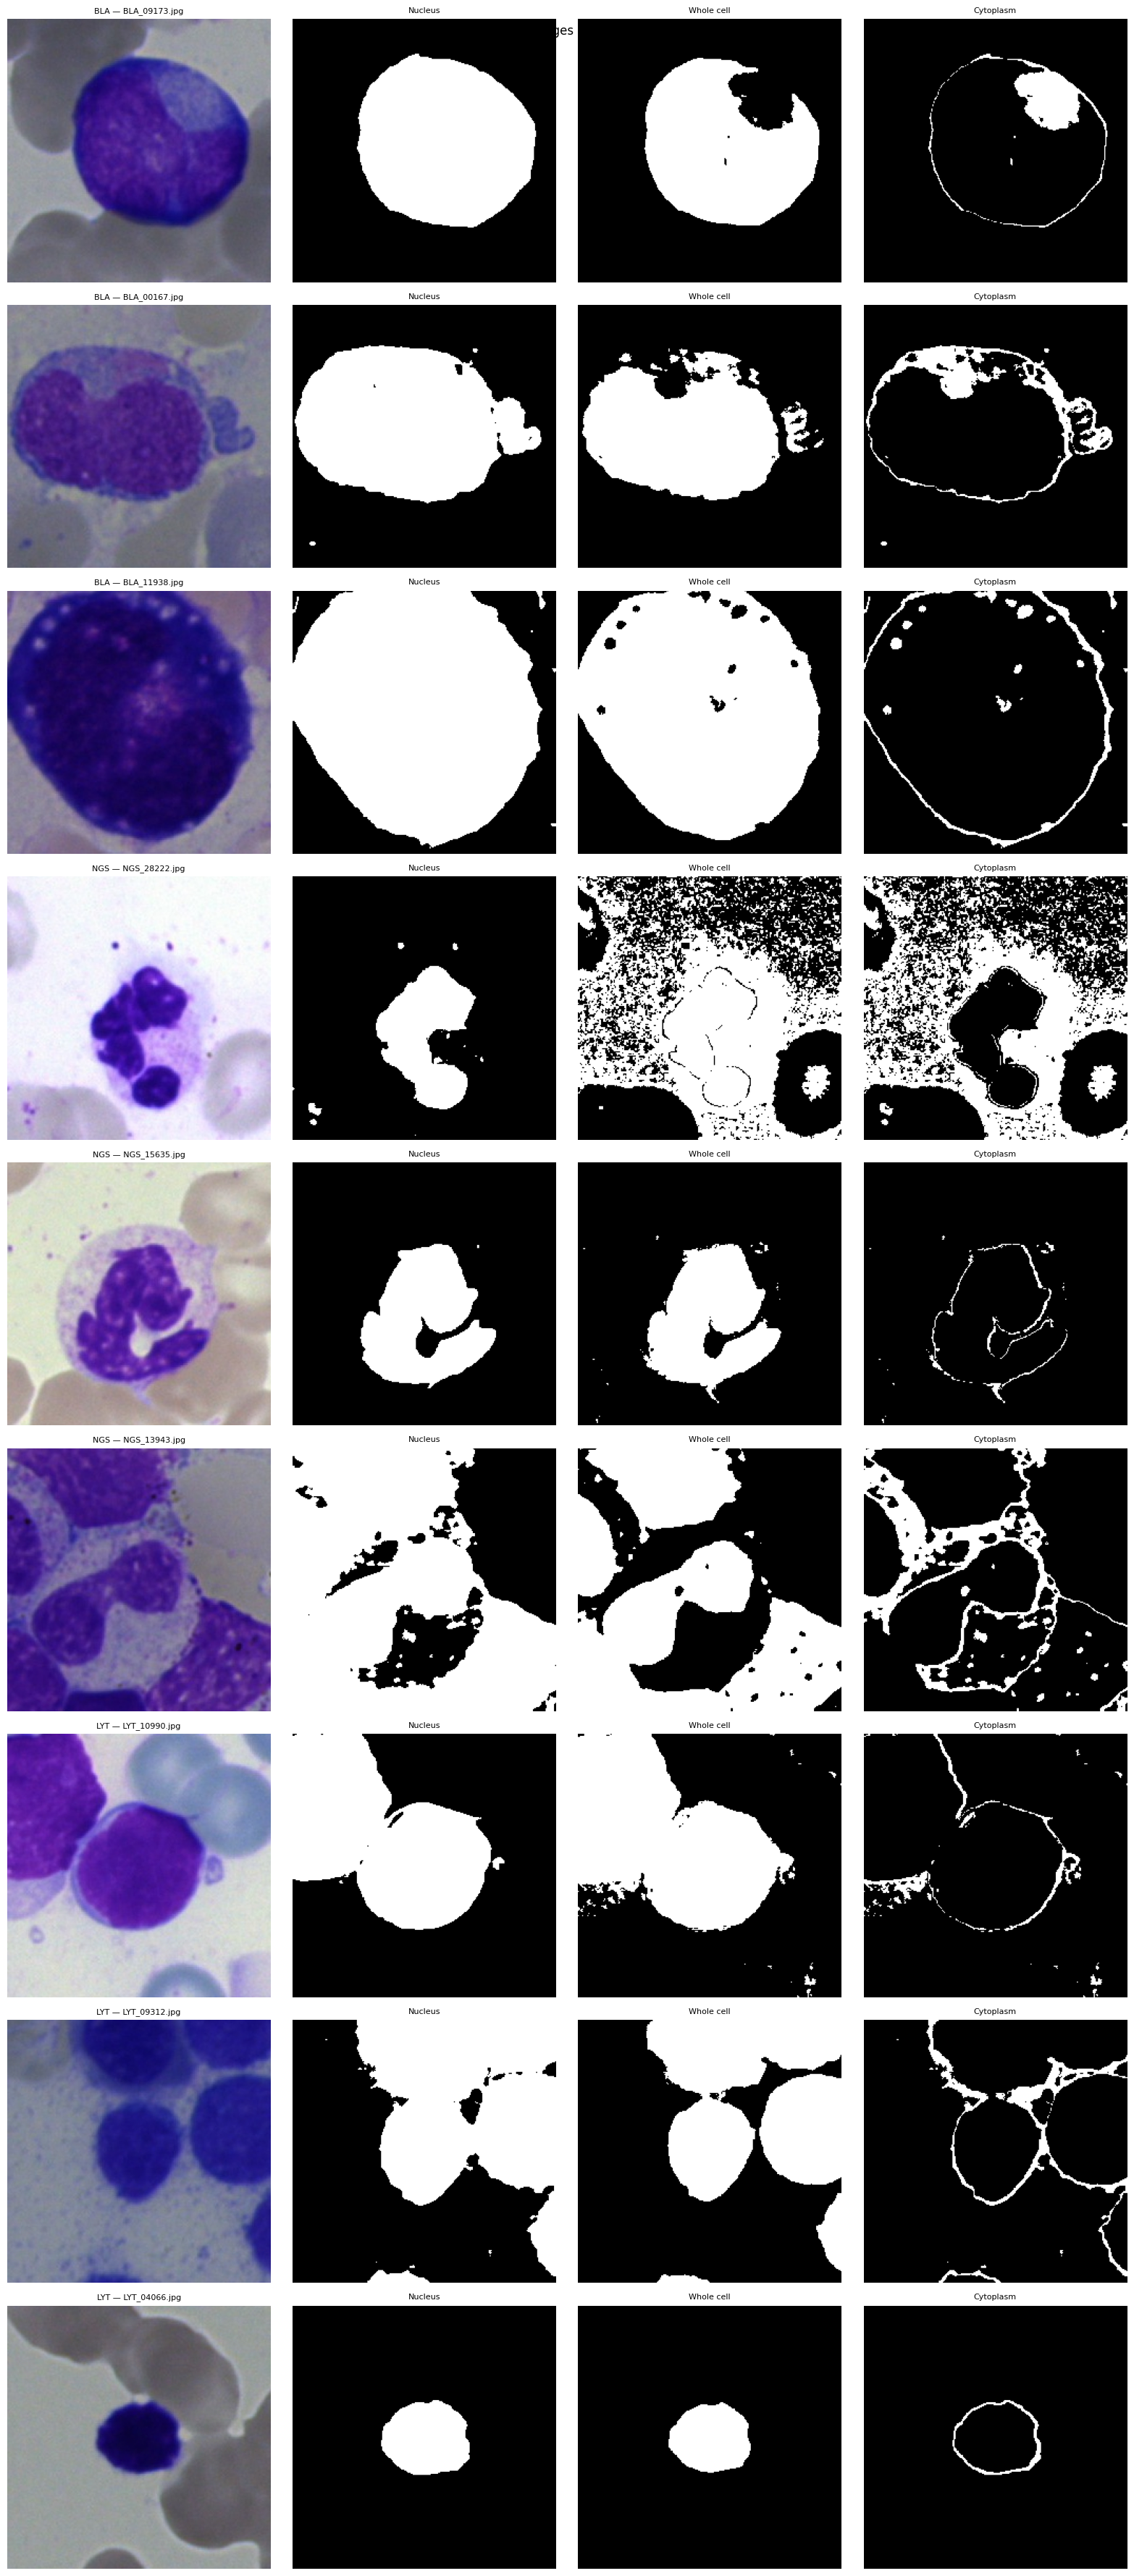

✓ Saved segmentation_check_filtered.png


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random

random.seed(42)
sample_dir = '/content/sample_3class/'

# Pick 3 random images from each class
fig, axes = plt.subplots(9, 4, figsize=(16, 36))
row_idx = 0

for cls in ['BLA', 'NGS', 'LYT']:
    cls_path = os.path.join(sample_dir, cls)
    all_images = os.listdir(cls_path)
    selected = random.sample(all_images, 3)  # 3 random images per class

    for fname in selected:
        img_path = os.path.join(cls_path, fname)
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        n_mask, c_mask, cy_mask = segment_cell_regions(img_bgr)

        axes[row_idx, 0].imshow(img_rgb)
        axes[row_idx, 0].set_title(f'{cls} — {fname}', fontsize=8)
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(n_mask, cmap='gray')
        axes[row_idx, 1].set_title('Nucleus', fontsize=8)
        axes[row_idx, 1].axis('off')

        axes[row_idx, 2].imshow(c_mask, cmap='gray')
        axes[row_idx, 2].set_title('Whole cell', fontsize=8)
        axes[row_idx, 2].axis('off')

        axes[row_idx, 3].imshow(cy_mask, cmap='gray')
        axes[row_idx, 3].set_title('Cytoplasm', fontsize=8)
        axes[row_idx, 3].axis('off')

        row_idx += 1

plt.suptitle('Segmentation check — 3 images per class from filtered dataset',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/segmentation_check_filtered.png',
            dpi=80, bbox_inches='tight')
plt.show()
print("✓ Saved segmentation_check_filtered.png")

In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm

# column names
regions       = ['wholecell', 'nucleus', 'cytoplasm']
shape_names   = ['convexity','compactness','elongation','eccentricity',
                 'roundness','solidity','area','perimeter']
color_names   = ['R_mean','R_var','R_kurt','R_skew','R_entropy',
                 'G_mean','G_var','G_kurt','G_skew','G_entropy',
                 'B_mean','B_var','B_kurt','B_skew','B_entropy']
texture_names = ['contrast','dissimilarity','homogeneity','energy','correlation']

all_feat_names = []
for r in regions:
    for n in shape_names:   all_feat_names.append(f'{r}_{n}')
    for n in color_names:   all_feat_names.append(f'{r}_{n}')
    for n in texture_names: all_feat_names.append(f'{r}_{n}')
all_feat_names.append('label')

print(f"Total feature columns: {len(all_feat_names)-1}")
print(f"Expected: 84 features + 1 label = 85 columns total")

# extract all features from one image
def extract_features_one_image(img_path, label):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    try:
        n_mask, c_mask, cy_mask = segment_cell_regions(img_bgr)
    except Exception:
        return None

    # quality checks
    n_area = np.sum(n_mask > 0)
    c_area = np.sum(c_mask > 0)
    if n_area < 1000:      # nucleus too small = bad segmentation
        return None
    if c_area < n_area:    # whole cell smaller than nucleus = impossible
        return None


    row = []
    for mask in [c_mask, n_mask, cy_mask]:  # whole cell, nucleus, cytoplasm
        row += shape_features(mask)          # 8 features
        row += color_features(img_rgb, mask) # 15 features
        row += texture_features(img_gray, mask) # 5 features
    row.append(label)
    return row

# loop through all 3000 images
sample_dir = '/content/sample_3class/'
records    = []
failed     = 0

for cls in ['BLA', 'NGS', 'LYT']:
    cls_path = os.path.join(sample_dir, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.png', '.tiff'))]
    print(f"\nProcessing {cls}: {len(images)} images")
    for fname in tqdm(images, desc=cls):
        img_path = os.path.join(cls_path, fname)
        result   = extract_features_one_image(img_path, cls)
        if result is not None:
            records.append(result)
        else:
            failed += 1

# build dataframe
df = pd.DataFrame(records, columns=all_feat_names)

#save to Colab and Drive
df.to_csv('/content/metadata.csv', index=False)
df.to_csv('/content/drive/MyDrive/dissertation/metadata.csv', index=False)

# summary
print(f"\n{'='*50}")
print(f"✓ metadata.csv saved to Colab and Drive")
print(f"✓ Shape: {df.shape}")
print(f"  rows = cells successfully processed")
print(f"  cols = 84 features + 1 label")
print(f"\n✓ Failed/skipped: {failed} images")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nAny missing values: {df.isnull().sum().sum()}")
print(f"\nFirst row preview:")
print(df.iloc[0])

Total feature columns: 84
Expected: 84 features + 1 label = 85 columns total

Processing BLA: 1000 images


BLA: 100%|██████████| 1000/1000 [01:20<00:00, 12.40it/s]



Processing NGS: 1000 images


NGS: 100%|██████████| 1000/1000 [01:34<00:00, 10.59it/s]



Processing LYT: 1000 images


LYT:  68%|██████▊   | 677/1000 [00:59<00:23, 13.63it/s]